In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
import random

Linear Regression

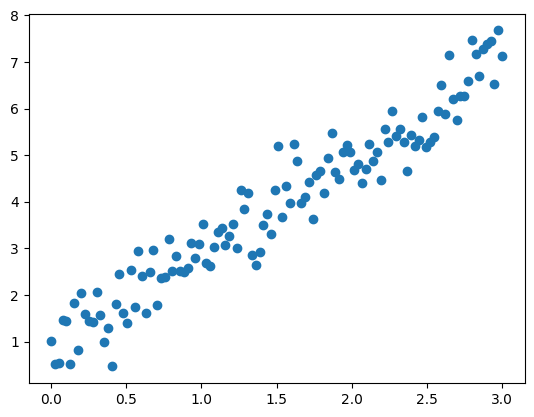

In [34]:
train_x = np.linspace(0, 3, 120)
train_y = 2 * train_x + 0.9 + np.random.randn(*train_x.shape) * 0.5

plt.scatter(train_x,train_y)

In [20]:
input_dim = 1
output_dim = 1
learning_rate = 0.1

# This is our weight matrix
w = tf.Variable([[100.0]])
# This is our bias vector
b = tf.Variable(tf.zeros(shape=(output_dim,)))

def f(x):
  return tf.matmul(x,w) + b

def compute_loss(labels, predictions):
  return tf.reduce_mean(tf.square(labels - predictions))

In [21]:
def train_on_batch(x, y):
  with tf.GradientTape() as tape:
    predictions = f(x)
    loss = compute_loss(y, predictions)
    # Note that `tape.gradient` works with a list as well (w, b).
    dloss_dw, dloss_db = tape.gradient(loss, [w, b])
  w.assign_sub(learning_rate * dloss_dw)
  b.assign_sub(learning_rate * dloss_db)
  return loss

In [22]:
indices = np.random.permutation(len(train_x))
features = tf.constant(train_x[indices],dtype=tf.float32)
labels = tf.constant(train_labels[indices],dtype=tf.float32)

In [23]:
batch_size = 4
for epoch in range(10):
  for i in range(0,len(features),batch_size):
    loss = train_on_batch(tf.reshape(features[i:i+batch_size],(-1,1)),tf.reshape(labels[i:i+batch_size],(-1,1)))
  print('Epoch %d: last batch loss = %.4f' % (epoch, float(loss)))

Epoch 0: last batch loss = 23.5391
Epoch 1: last batch loss = 1.9665
Epoch 2: last batch loss = 0.3061
Epoch 3: last batch loss = 0.1840
Epoch 4: last batch loss = 0.1766
Epoch 5: last batch loss = 0.1766
Epoch 6: last batch loss = 0.1768
Epoch 7: last batch loss = 0.1769
Epoch 8: last batch loss = 0.1769
Epoch 9: last batch loss = 0.1769


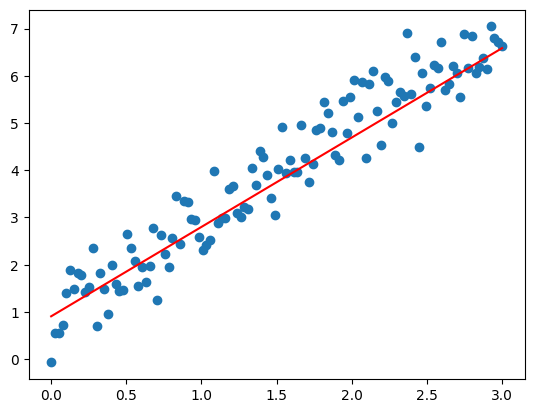

In [24]:
plt.scatter(train_x,train_labels)
x = np.array([min(train_x),max(train_x)])
y = w.numpy()[0,0]*x+b.numpy()[0]
plt.plot(x,y,color='red')

Computational Graph and GPU Computations

In [ ]:
# Same code as above, but with @tf.function decorator to compile the function into a graph for better performance.

@tf.function
def train_on_batch(x, y):
  with tf.GradientTape() as tape:
    predictions = f(x)
    loss = compute_loss(y, predictions)
    # Note that `tape.gradient` works with a list as well (w, b).
    dloss_dw, dloss_db = tape.gradient(loss, [w, b])
  w.assign_sub(learning_rate * dloss_dw)
  b.assign_sub(learning_rate * dloss_db)
  return loss

In [43]:
np.random.seed(0)

n = 100
X, Y = make_classification(n_samples = n, n_features=2,
                           n_redundant=0, n_informative=2, flip_y=0.05,class_sep=1.5)
X = X.astype(np.float32)
Y = Y.astype(np.int32)

split = [ 70*n//100, (15+70)*n//100 ]
train_x, valid_x, test_x = np.split(X, split)
train_labels, valid_labels, test_labels = np.split(Y, split)

C:\Users\jsand\AppData\Local\Temp\ipykernel_19776\3155907829.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


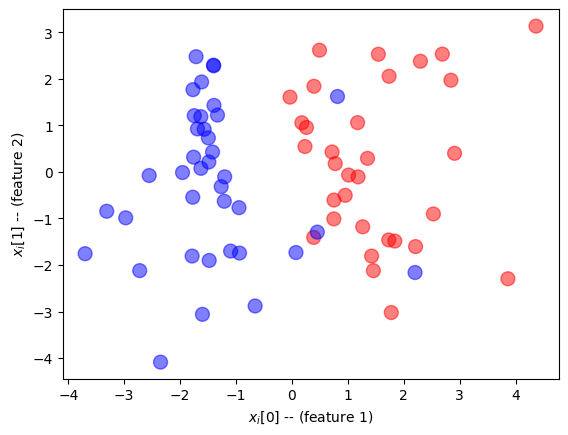

In [44]:
def plot_dataset(features, labels, W=None, b=None):
    # prepare the plot
    fig, ax = plt.subplots(1, 1)
    ax.set_xlabel('$x_i[0]$ -- (feature 1)')
    ax.set_ylabel('$x_i[1]$ -- (feature 2)')
    colors = ['r' if l else 'b' for l in labels]
    ax.scatter(features[:, 0], features[:, 1], marker='o', c=colors, s=100, alpha = 0.5)
    if W is not None:
        min_x = min(features[:,0])
        max_x = max(features[:,1])
        min_y = min(features[:,1])*(1-.1)
        max_y = max(features[:,1])*(1+.1)
        cx = np.array([min_x,max_x],dtype=np.float32)
        cy = (0.5-W[0]*cx-b)/W[1]
        ax.plot(cx,cy,'g')
        ax.set_ylim(min_y,max_y)
    fig.show()

plot_dataset(train_x, train_labels)

In [45]:
train_x_norm = (train_x-np.min(train_x)) / (np.max(train_x)-np.min(train_x))
valid_x_norm = (valid_x-np.min(train_x)) / (np.max(train_x)-np.min(train_x))
test_x_norm = (test_x-np.min(train_x)) / (np.max(train_x)-np.min(train_x))

In [46]:
W = tf.Variable(tf.random.normal(shape=(2,1)),dtype=tf.float32)
b = tf.Variable(tf.zeros(shape=(1,),dtype=tf.float32))

learning_rate = 0.1

@tf.function
def train_on_batch(x, y):
  with tf.GradientTape() as tape:
    z = tf.matmul(x, W) + b
    loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=y,logits=z))
  dloss_dw, dloss_db = tape.gradient(loss, [W, b])
  W.assign_sub(learning_rate * dloss_dw)
  b.assign_sub(learning_rate * dloss_db)
  return loss

Epoch 0: last batch loss = 0.2524
Epoch 1: last batch loss = 0.3426
Epoch 2: last batch loss = 0.2039
Epoch 3: last batch loss = 0.2755
Epoch 4: last batch loss = 0.1834
Epoch 5: last batch loss = 0.4119
Epoch 6: last batch loss = 0.4579
Epoch 7: last batch loss = 0.1060
Epoch 8: last batch loss = 0.1495
Epoch 9: last batch loss = 0.1275


C:\Users\jsand\AppData\Local\Temp\ipykernel_19776\3155907829.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


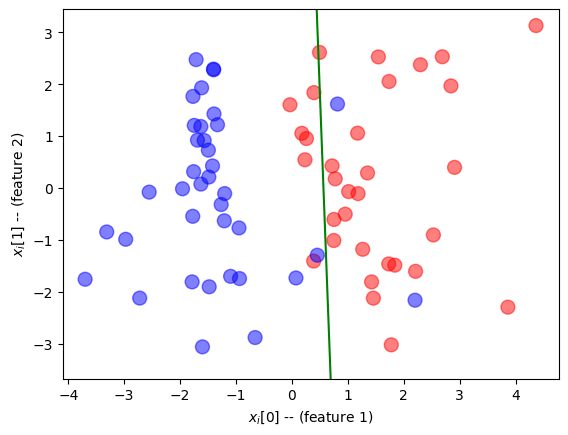

In [54]:
dataset = tf.data.Dataset.from_tensor_slices((train_x_norm.astype(np.float32), train_labels.astype(np.float32)))
dataset = dataset.shuffle(128).batch(2)

for epoch in range(10):
  for step, (x, y) in enumerate(dataset):
    loss = train_on_batch(x, tf.expand_dims(y,1))
  print('Epoch %d: last batch loss = %.4f' % (epoch, float(loss)))

plot_dataset(train_x,train_labels,W.numpy(),b.numpy())

Using TensorFlow/Keras Optimizers

In [55]:
optimizer = tf.keras.optimizers.Adam(0.01)

W = tf.Variable(tf.random.normal(shape=(2,1)))
b = tf.Variable(tf.zeros(shape=(1,),dtype=tf.float32))

@tf.function
def train_on_batch(x, y):
  vars = [W, b]
  with tf.GradientTape() as tape:
    z = tf.sigmoid(tf.matmul(x, W) + b)
    loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(z,y))
    correct_prediction = tf.equal(tf.round(y), tf.round(z))
    acc = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))
    grads = tape.gradient(loss, vars)
    optimizer.apply_gradients(zip(grads,vars))
  return loss,acc

for epoch in range(20):
  for step, (x, y) in enumerate(dataset):
    loss,acc = train_on_batch(tf.reshape(x,(-1,2)), tf.reshape(y,(-1,1)))
  print('Epoch %d: last batch loss = %.4f, acc = %.4f' % (epoch, float(loss),acc))

Epoch 0: last batch loss = 7.6985, acc = 0.5000
Epoch 1: last batch loss = 8.6345, acc = 0.0000
Epoch 2: last batch loss = 6.7555, acc = 1.0000
Epoch 3: last batch loss = 7.4643, acc = 0.5000
Epoch 4: last batch loss = 7.1091, acc = 1.0000
Epoch 5: last batch loss = 7.9959, acc = 0.5000
Epoch 6: last batch loss = 7.5011, acc = 0.5000
Epoch 7: last batch loss = 6.8222, acc = 1.0000
Epoch 8: last batch loss = 6.5834, acc = 1.0000
Epoch 9: last batch loss = 6.6476, acc = 1.0000
Epoch 10: last batch loss = 7.2454, acc = 1.0000
Epoch 11: last batch loss = 7.9401, acc = 0.5000
Epoch 12: last batch loss = 7.0105, acc = 1.0000
Epoch 13: last batch loss = 6.3281, acc = 1.0000
Epoch 14: last batch loss = 8.9023, acc = 0.5000
Epoch 15: last batch loss = 6.5066, acc = 1.0000
Epoch 16: last batch loss = 6.2757, acc = 1.0000
Epoch 17: last batch loss = 7.0545, acc = 1.0000
Epoch 18: last batch loss = 5.5042, acc = 1.0000
Epoch 19: last batch loss = 7.2409, acc = 0.5000
